In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
%load_ext autoreload
%autoreload 2

In [2]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
import yfinance as yf
import statsmodels.api as sm
import data as dt
import models as md
import backtest as bt
from pathlib import Path
print("OK")

output_dir = Path("../Outputs")
residuals = pd.read_csv(output_dir / "residuals.csv", index_col = 0, parse_dates = True)
print(f"Residuals loaded: {residuals.shape}")
print(f"Tickers: {residuals.columns.tolist()}")

OK
Residuals loaded: (903, 20)
Tickers: ['DAL', 'UAL', 'AAL', 'LUV', 'ALK', 'JBLU', 'UNP', 'CSX', 'NSC', 'CP', 'CNI', 'UPS', 'FDX', 'JBHT', 'ODFL', 'KNX', 'SAIA', 'SNDR', 'CHRW', 'EXPD']


In [3]:
stocks = dt.stocks

In [4]:
univ = ['DAL', 'UAL', 'AAL', 'LUV', 'ALK', 'JBLU', 'UNP', 'CSX', 'NSC', 'CP', 'CNI', 'UPS', 'FDX', 'JBHT', 'ODFL', 'KNX', 'SAIA', 'SNDR', 'CHRW', 'EXPD']
px = yf.download(univ, start = '2016-01-01', auto_adjust = True, progress = False)['Close']
px = px.rename(columns = {'BZ=F':'Brent', '^VIX':'VIX'})
ret = px.pct_change().dropna()
print(f"Downloaded: {px.shape} | {px.index[0].date()} → {px.index[-1].date()}")

Downloaded: (2659, 20) | 2016-01-04 → 2026-07-31


In [5]:
output_dir = Path("../Outputs")
stocks_returns = pd.read_csv(output_dir / "stocks_returns.csv", index_col = 0, parse_dates = True)
macro_returns = pd.read_csv(output_dir / "macro_returns.csv", index_col = 0, parse_dates = True)
ticker = 'DAL'
zwin = 45
start = '2016-01-01'
end = '2026-07-31'
residuals = pd.read_csv(output_dir / "residuals.csv", index_col = 0, parse_dates = True)
prices = pd.read_csv(output_dir / "stocks_returns.csv", index_col = 0, parse_dates = True)

print(f"Residuals: {residuals.shape} | {residuals.index[0].date()} → {residuals.index[-1].date()}")
print(f"Prices: {prices.shape} | {prices.index[0].date()} → {prices.index[-1].date()}")
print(f"Available tickers: {residuals.columns.tolist()}")

Residuals: (903, 20) | 2022-12-15 → 2026-07-30
Prices: (2336, 20) | 2017-04-07 → 2026-07-30
Available tickers: ['DAL', 'UAL', 'AAL', 'LUV', 'ALK', 'JBLU', 'UNP', 'CSX', 'NSC', 'CP', 'CNI', 'UPS', 'FDX', 'JBHT', 'ODFL', 'KNX', 'SAIA', 'SNDR', 'CHRW', 'EXPD']


In [6]:
zscores_full = md.compute_rolling_zscore(residuals, window = zwin)
if ticker not in residuals.columns:
    print(f"ERROR: {ticker} not in residuals. Available: {residuals.columns.tolist()}")
else:

    price_s = prices[ticker].dropna()
    z_s = zscores_full[ticker].dropna()

    common = price_s.index.intersection(z_s.index)
    common = common[(common >= start) & (common <= end)]

    print(f"Common dates in range: {len(common)}")
    if len(common) == 0:
        print(f"No overlap. Price range: {price_s.index[0].date()} → {price_s.index[-1].date()}")
        print(f"Z-score range: {z_s.index[0].date()} → {z_s.index[-1].date()}")
    else:
        price_plot = price_s.loc[common]
        z_plot = z_s.loc[common]
        print(f"Price range: {price_plot.min():.2f} → {price_plot.max():.2f}")
        print(f"Z-score range: {z_plot.min():.3f} → {z_plot.max():.3f}")
        print(f"Signals (z>+2): {(z_plot > 2).sum()} (z<-2): {(z_plot < -2).sum()}")

Common dates in range: 894
Price range: -0.11 → 0.11
Z-score range: -4.157 → 3.600
Signals (z>+2): 26 (z<-2): 26


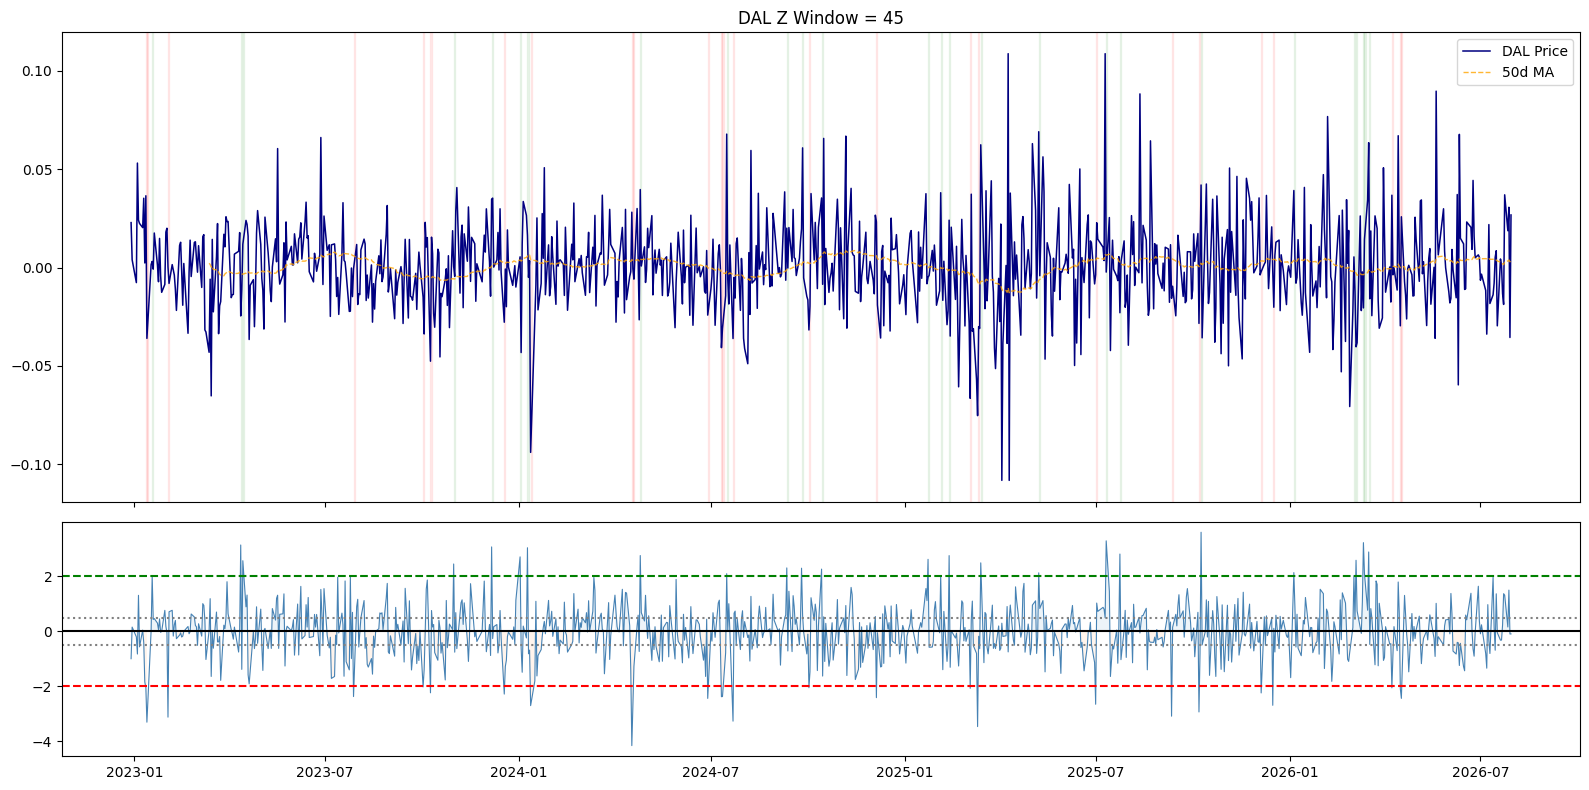

In [7]:
if len(common) > 0:
    price_plot = price_plot.sort_index()
    z_plot = z_plot.sort_index()
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize = (16,8), sharex = True, gridspec_kw = {"height_ratios":[2,1]})

    ax1.plot(price_plot.index, price_plot.values, color = "navy", linewidth = 1.1, label = f"{ticker} Price")

    ma50 = price_plot.rolling(50).mean()

    ax1.plot(ma50.index, ma50.values, color = "orange", linestyle="--", linewidth = 1, alpha = .8, label = "50d MA")

    for date, z in z_plot.items():

        if z > 2:
            ax1.axvspan(date, date + pd.Timedelta(days = 1), color = "green", alpha = .07)

        elif z < -2:
            ax1.axvspan(date, date + pd.Timedelta(days = 1), color = "red", alpha = .07)

    ax1.set_title(f"{ticker} Z Window = {zwin}")
    ax1.legend()

    ax2.plot(z_plot.index, z_plot.values, color = "steelblue", linewidth = .8)

    ax2.axhline(2, color = "green", ls = "--")
    ax2.axhline(-2, color = "red", ls = "--")
    ax2.axhline(bt.exit_threshold, color = "gray", ls = ":")
    ax2.axhline(-bt.exit_threshold, color = "gray", ls = ":")
    ax2.axhline(0, color = "black")

    ax2.fill_between(z_plot.index, z_plot.values, 0, where = z_plot > 0, alpha = .08)

    ax2.fill_between(z_plot.index, z_plot.values, 0, where = z_plot < 0, alpha = .08)

    plt.tight_layout()
    plt.show()

In [8]:
output_dir = Path("../Outputs")

prices = pd.read_csv(output_dir/"prices.csv", index_col = 0, parse_dates = True)
prices = prices.rename(columns={"BZ=F":"Brent","^VIX":"VIX"})
ret = prices.pct_change().dropna()
px = prices.copy()

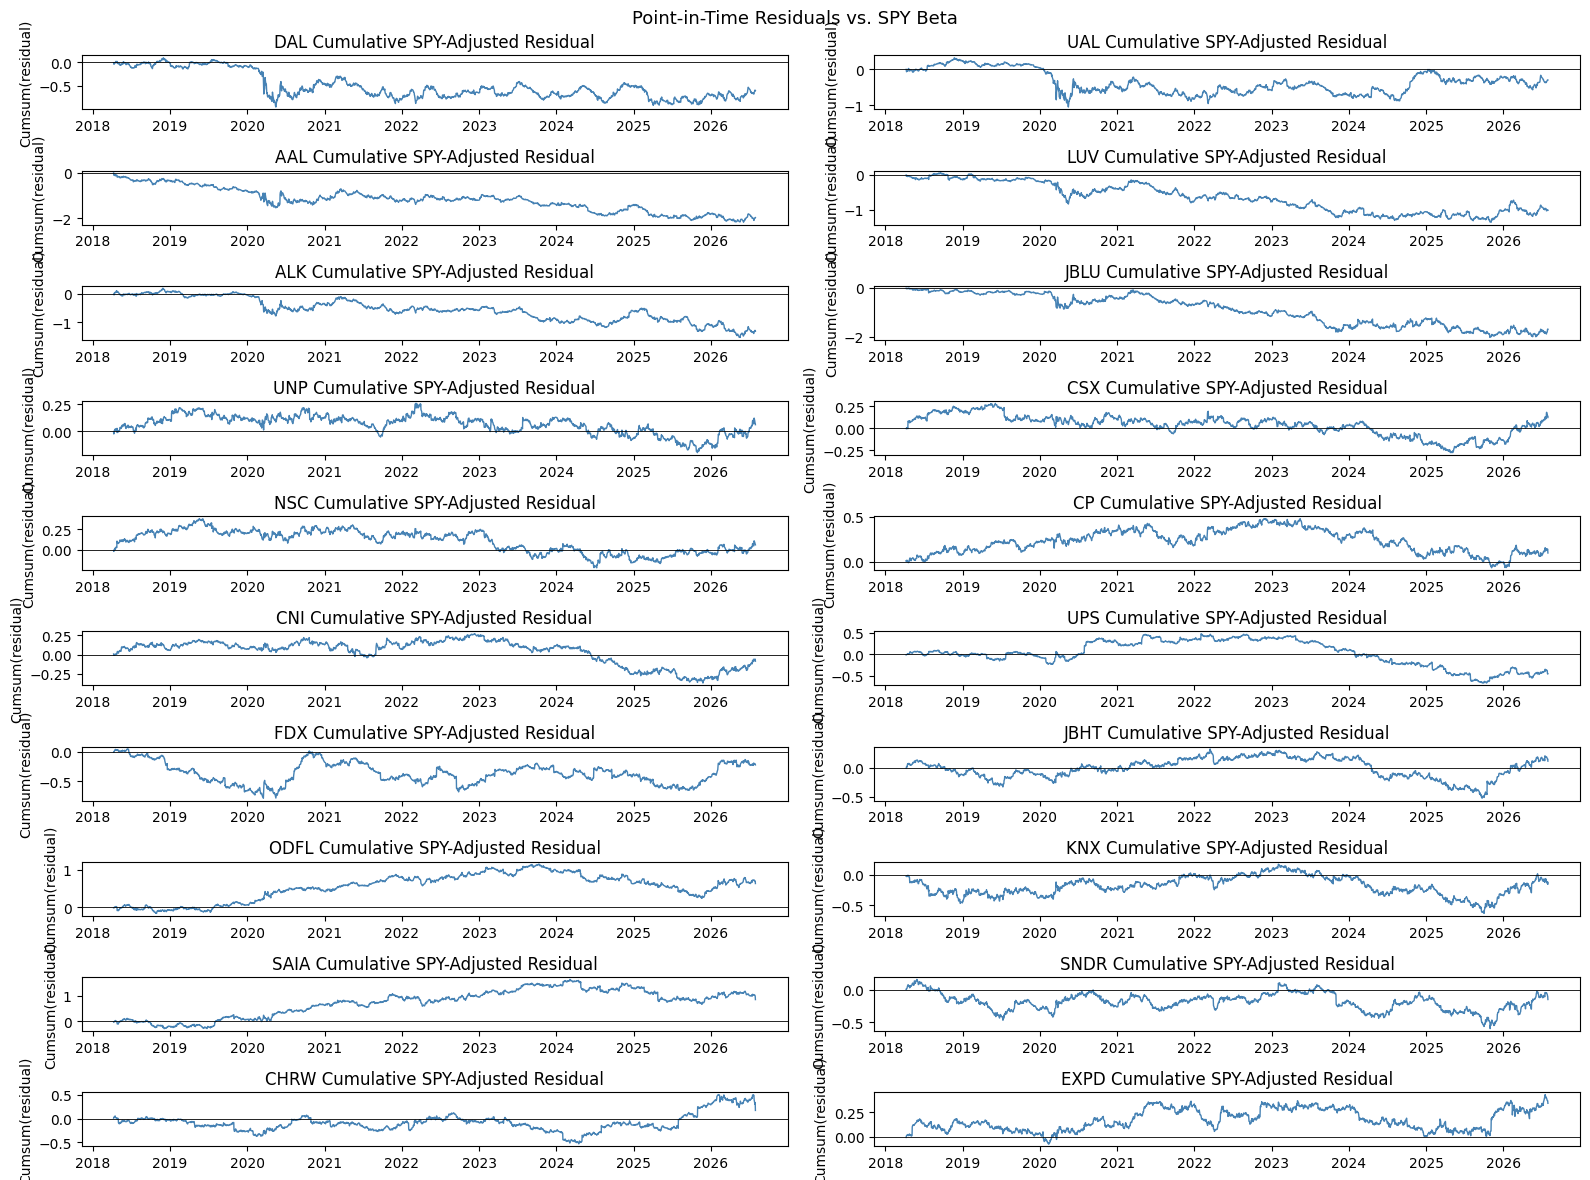

In [9]:
spy_ret = ret['SPY']
corr_r = ret[stocks].rolling(252).corr(spy_ret)
vol_r = ret[stocks].rolling(252).std()
vol_spy = ret['SPY'].rolling(252).std()
beta = corr_r.multiply(vol_r, axis = 0).divide(vol_spy, axis = 0)
resid = ret[stocks].sub(beta.multiply(spy_ret, axis = 0), axis = 0)
fig, axes = plt.subplots(10, 2, figsize = (16, 12))
axes = axes.flatten()
for i, t in enumerate(stocks):
    r = resid[t].dropna()
    axes[i].plot(r.cumsum(), color = 'steelblue', linewidth = 1.0)
    axes[i].axhline(0, color = 'black', linewidth = 0.6)
    axes[i].set_title(f"{t} Cumulative SPY-Adjusted Residual")
    axes[i].set_ylabel("Cumsum(residual)")
if len(stocks) < len(axes):
    axes[-1].set_visible(False)
plt.suptitle("Point-in-Time Residuals vs. SPY Beta", fontsize = 13)
plt.tight_layout()
plt.show()

Information Ratio (residual) vs. Sharpe Ratio (raw):
         IR     SR
DAL  -0.202  0.383
UAL  -0.079  0.365
AAL  -0.493  0.054
LUV  -0.367  0.168
ALK  -0.423  0.065
JBLU -0.391  0.040
UNP   0.038  0.634
CSX   0.073  0.644
NSC   0.035  0.618
CP    0.059  0.607
CNI  -0.057  0.463
UPS  -0.222  0.290
FDX  -0.094  0.440
JBHT  0.051  0.558
ODFL  0.271  0.836
KNX  -0.061  0.463
SAIA  0.253  0.718
SNDR -0.066  0.430
CHRW  0.072  0.465
EXPD  0.190  0.647


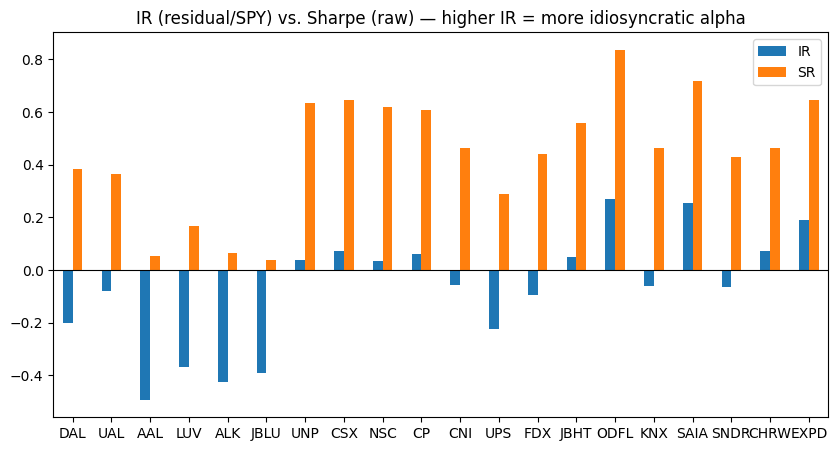

In [10]:
df_stats = pd.DataFrame({
    'IR': (resid[stocks].mean() / resid[stocks].std() * np.sqrt(252)),
    'SR': (ret[stocks].mean() / ret[stocks].std() * np.sqrt(252)),
})
print("Information Ratio (residual) vs. Sharpe Ratio (raw):")
print(df_stats.round(3).to_string())

df_stats.plot(kind = 'bar', figsize = (10, 5), title = "IR (residual/SPY) vs. Sharpe (raw) — higher IR = more idiosyncratic alpha")
plt.axhline(0, color = 'black', linewidth = 0.8)
plt.xticks(rotation = 0)
plt.show()

Volatility Comparison:
      Raw Vol  Residual Vol
DAL    0.4296        0.3575
UAL    0.5291        0.4558
AAL    0.5426        0.4842
LUV    0.3820        0.3334
ALK    0.4482        0.3754
JBLU   0.5629        0.5211
UNP    0.2577        0.1987
CSX    0.2711        0.1961
NSC    0.2799        0.2125
CP     0.2590        0.2011
CNI    0.2306        0.1805
UPS    0.2856        0.2448
FDX    0.3384        0.2850
JBHT   0.3073        0.2635
ODFL   0.3394        0.2828
KNX    0.3452        0.3032
SAIA   0.4650        0.4082
SNDR   0.3119        0.2747
CHRW   0.3046        0.2883
EXPD   0.2578        0.2152


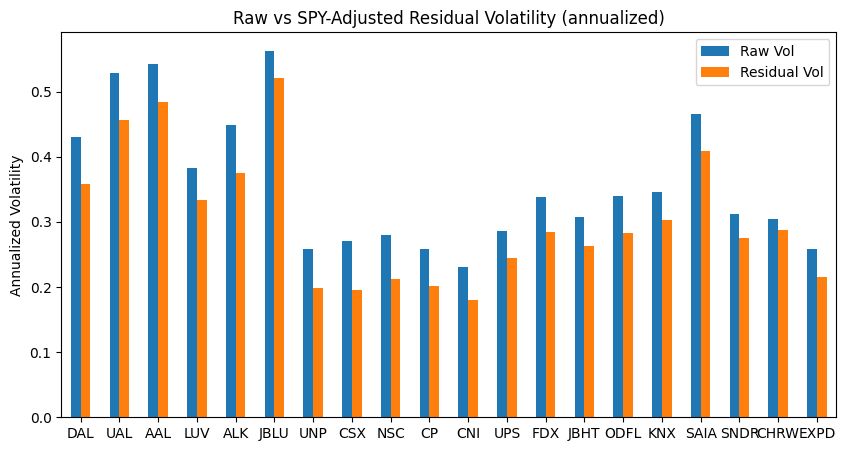

In [11]:
vol_compare = pd.DataFrame({
    'Raw Vol': ret[stocks].std() * np.sqrt(252),
    'Residual Vol': resid[stocks].std() * np.sqrt(252),
})
print("Volatility Comparison:")
print(vol_compare.round(4))

vol_compare.plot(kind = 'bar', figsize = (10,5),
    title = "Raw vs SPY-Adjusted Residual Volatility (annualized)")
plt.xticks(rotation = 0)
plt.ylabel("Annualized Volatility")
plt.show()

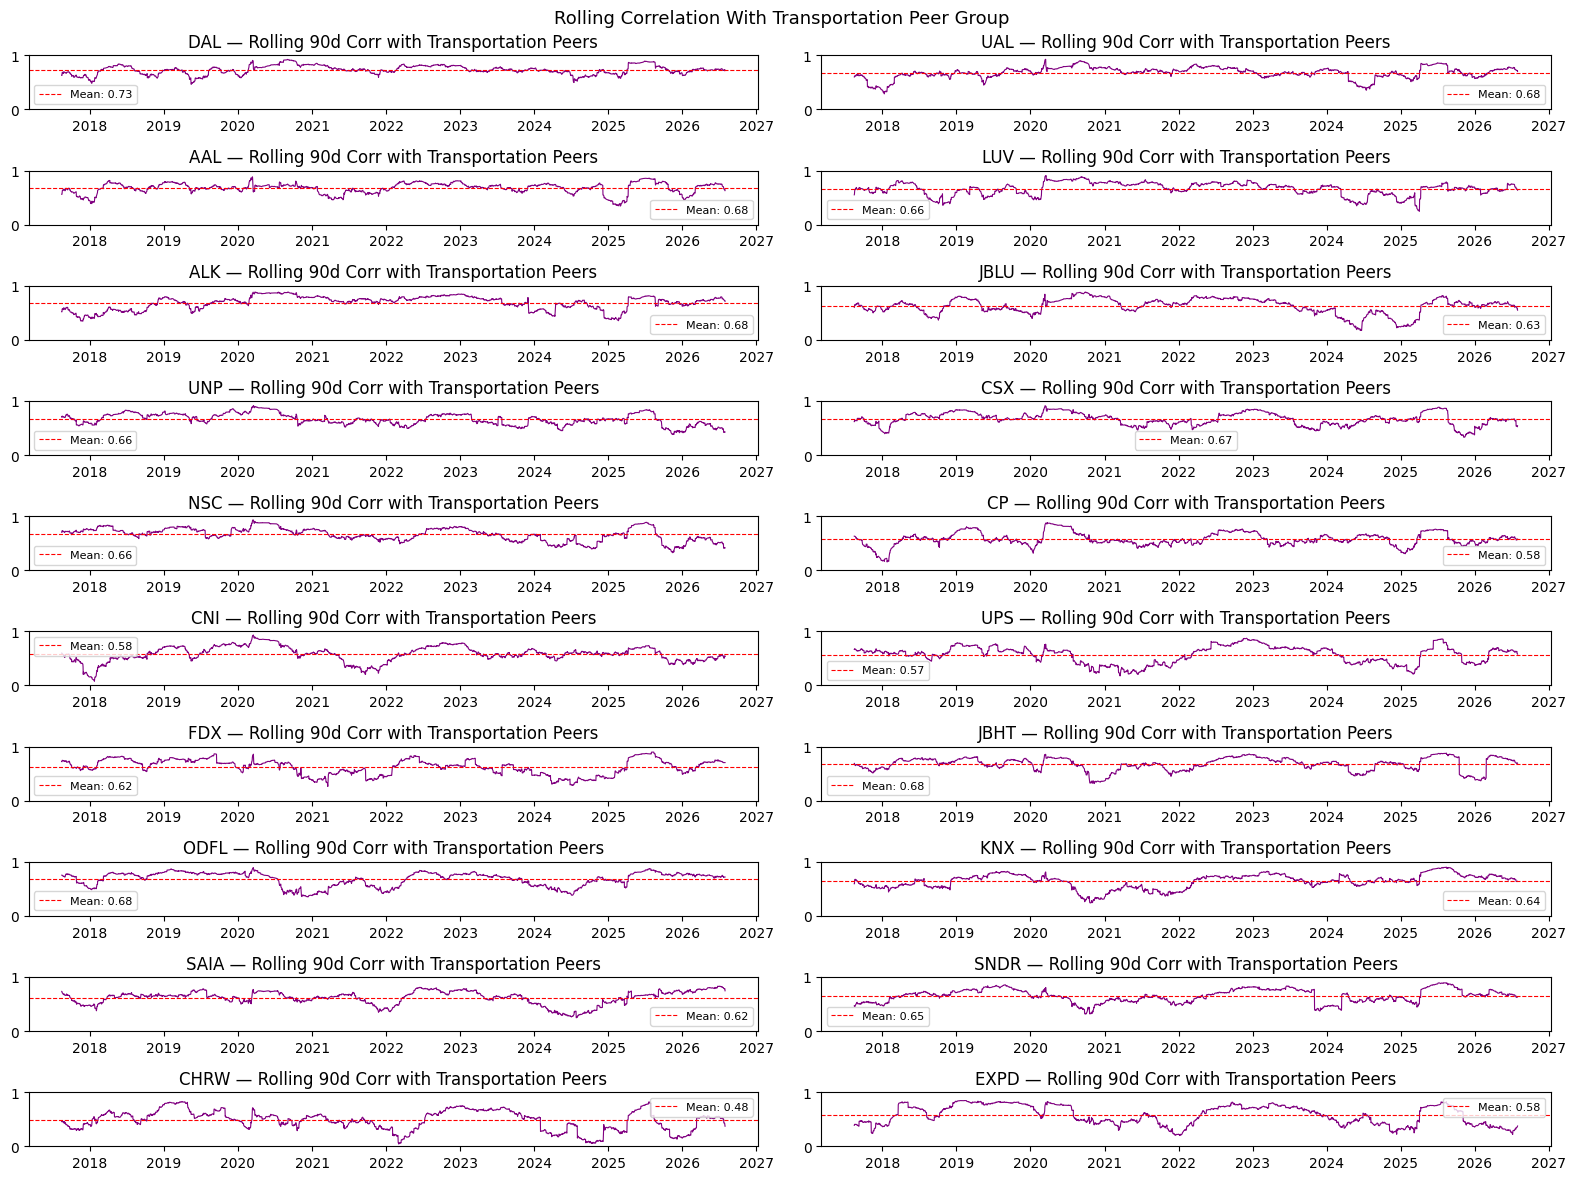

In [14]:
fig, axes = plt.subplots(10, 2, figsize = (16, 12))
axes = axes.flatten()
for i, t in enumerate(stocks):
    others = [x for x in stocks if x != t]
    rolling_corr = ret[t].rolling(90).corr(ret[others].mean(axis = 1))
    axes[i].plot(rolling_corr, color = 'purple', linewidth = 0.8)
    axes[i].axhline(rolling_corr.mean(), color = 'red', linestyle='--', linewidth = 0.8, label = f"Mean: {rolling_corr.mean():.2f}")
    axes[i].set_title(f"{t} — Rolling 90d Corr with Transportation Peers")
    axes[i].set_ylim(0, 1.0)
    axes[i].legend(fontsize = 8)
if len(stocks) < len(axes):
    axes[-1].set_visible(False)
plt.suptitle("Rolling Correlation With Transportation Peer Group", fontsize = 13)
plt.tight_layout()
plt.show()

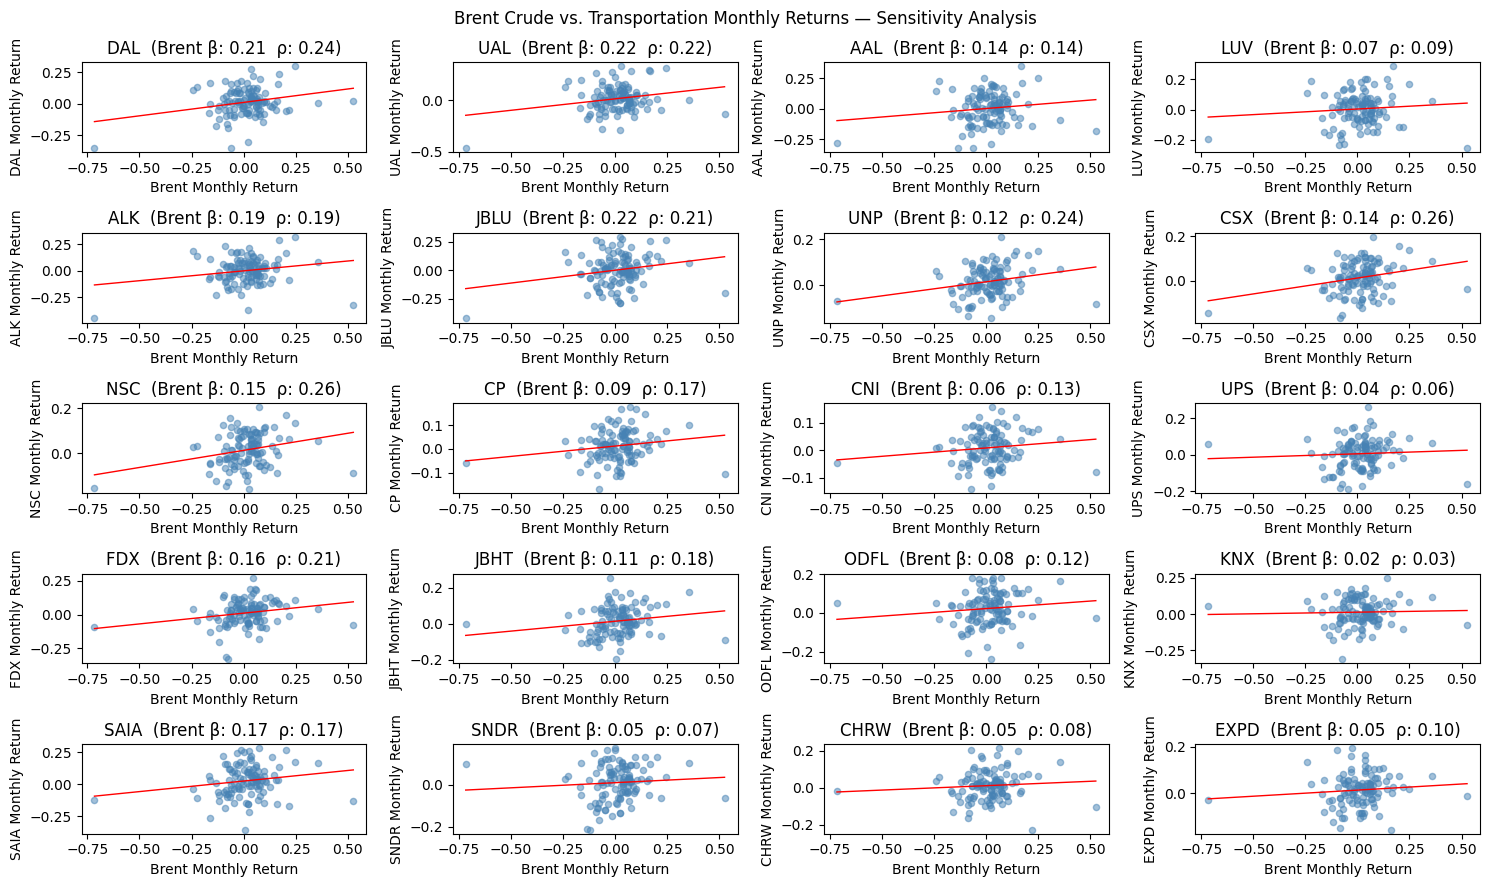

In [18]:
fig, axes = plt.subplots(5, 4, figsize = (15, 9))
axes = axes.flatten()
brent_monthly = ret['Brent'].resample('ME').sum()
for i, t in enumerate(stocks):
    stocks_monthly = ret[t].resample('ME').sum()
    common = brent_monthly.index.intersection(stocks_monthly.index)
    x = brent_monthly.loc[common]
    y = stocks_monthly.loc[common]
    axes[i].scatter(x, y, alpha = 0.5, s = 20, color = 'steelblue')
    m, b_, *_ = np.polyfit(x, y, 1)
    xl = np.linspace(x.min(), x.max(), 100)
    axes[i].plot(xl, m * xl + b_, color = 'red', linewidth = 1.0)
    corr = x.corr(y)
    axes[i].set_title(f"{t}  (Brent β: {m:.2f}  ρ: {corr:.2f})")
    axes[i].set_xlabel("Brent Monthly Return")
    axes[i].set_ylabel(f"{t} Monthly Return")
if len(stocks) < len(axes):
    axes[-1].set_visible(False)
plt.suptitle("Brent Crude vs. Transportation Monthly Returns — Sensitivity Analysis", fontsize = 12)
plt.tight_layout()
plt.show()

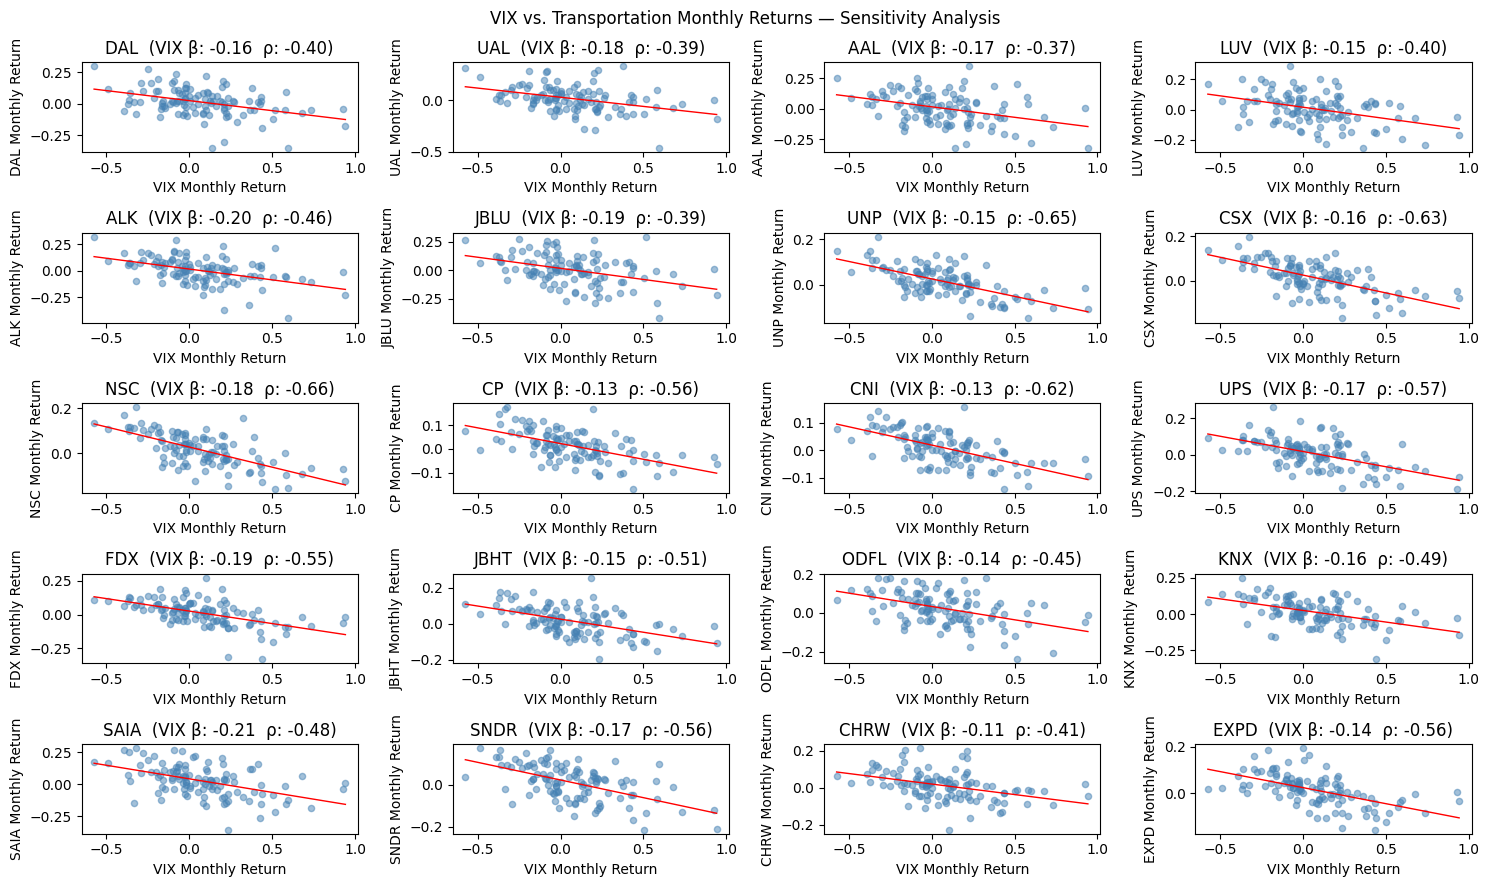

In [19]:
fig, axes = plt.subplots(5, 4, figsize = (15, 9))
axes = axes.flatten()
vix_monthly = ret['VIX'].resample('ME').sum()
for i, t in enumerate(stocks):
    stocks_monthly = ret[t].resample('ME').sum()
    common = vix_monthly.index.intersection(stocks_monthly.index)
    x = vix_monthly.loc[common]
    y = stocks_monthly.loc[common]
    axes[i].scatter(x, y, alpha = 0.5, s = 20, color = 'steelblue')
    m, b_, *_ = np.polyfit(x, y, 1)
    xl = np.linspace(x.min(), x.max(), 100)
    axes[i].plot(xl, m * xl + b_, color = 'red', linewidth = 1.0)
    corr = x.corr(y)
    axes[i].set_title(f"{t}  (VIX β: {m:.2f}  ρ: {corr:.2f})")
    axes[i].set_xlabel("VIX Monthly Return")
    axes[i].set_ylabel(f"{t} Monthly Return")
if len(stocks) < len(axes):
    axes[-1].set_visible(False)
plt.suptitle("VIX vs. Transportation Monthly Returns — Sensitivity Analysis", fontsize=12)
plt.tight_layout()
plt.show()

,Window,Sharpe,Annual Return,Turnover
0,20,0.045,0.0071,65.653
1,30,-0.150,-0.0232,64.366
2,45,-0.368,-0.0558,63.483
3,60,-0.655,-0.1048,63.348
4,75,-0.550,-0.0828,64.065
5,90,-0.555,-0.0859,64.248


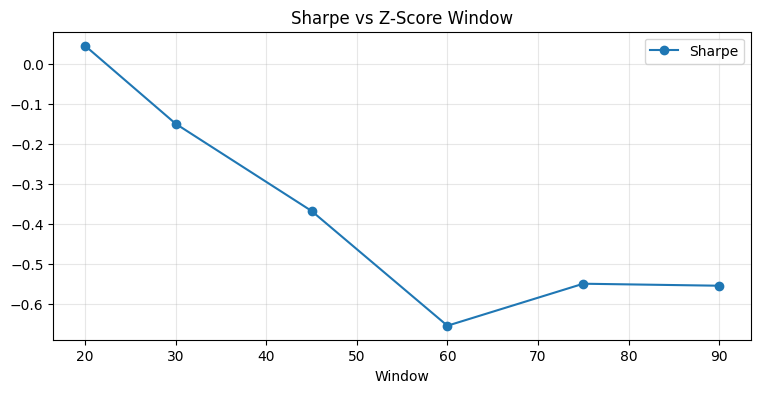

In [20]:
windows = [20, 30, 45, 60, 75, 90]
summary = []

for w in windows:
    z = md.compute_rolling_zscore(residuals, window = w).dropna()
    signals = bt.generate_signals(z, top_n = bt.top_n, exit_ = bt.exit_threshold,
                                  min_hold = bt.min_hold_days, momentum = True)
    
    positions = bt.construct_portfolio(signals, zscores = z, residuals = residuals)
    net, trades = bt.compute_portfolio_returns(positions, stocks_returns)
    perf = bt.compute_performance(net, trades, macro_returns)
    summary.append({"Window": w, "Sharpe": perf["sharpe_ratio"], "Annual Return": perf["annualized_returns"],"Turnover": perf["ann_turnover"]})
summary_df = pd.DataFrame(summary)
display(summary_df)
summary_df.plot(x = "Window", y = "Sharpe", marker = "o", figsize = (9,4))
plt.title("Sharpe vs Z-Score Window")
plt.grid(alpha = 0.3)
plt.show()